# Dunnhumby: The Complete Journey | 07 Campaign Impact

**Question:** did being targeted by a campaign make households spend more, and did the extra sales cover the coupon cost?

**Why this needs a causal design:** notebook 02 showed that targeted households already spent more than 4x as much per week as never-targeted ones before any campaign. A simple targeted vs non-targeted comparison would credit the campaign with a gap that existed anyway. Comparing coupon redeemers with non-redeemers is even worse, because households choose to redeem, and the keenest shoppers redeem most. This notebook estimates the effect of **being targeted** (intention to treat), which is also the decision the retailer actually controls.

**Design**
1. **Stacked difference-in-differences.** Each campaign is its own mini-experiment (a "stack") with a 6-week pre-period, the campaign weeks, and 4 weeks after. The effect is the change in the targeted households' weekly spend from pre to during, minus the same change for comparable untargeted households. Differencing removes fixed differences in spending level between households, and stacking compares each campaign only with households that were untreated at that time. This avoids the known bias of a single two-way fixed effects regression when treatment starts at different times (Goodman-Bacon, 2021).
2. **Clean windows.** Notebook 02 found that 56% of targeted households had overlapping campaigns. A targeted household enters a stack only if no other campaign of theirs overlaps the pre-period or the campaign itself, so the effect is not mixed with other campaigns.
3. **Two control groups.**
   - **Targeted at another time (main estimate):** households the retailer did target, but with no campaign between the start of this stack's pre-period and 4 weeks after its end. The retailer's own selection chose them too, so they are much closer to the treated households.
   - **Never targeted (robustness check):** households that received no campaign at all during the two years. They are mostly much lighter shoppers, so fewer treated households find a match, and matches are more exposed to regression to the mean (see section 5).

   The main group was chosen before looking at the real results, based on this reasoning and a test on simulated data with a known effect, where the never-targeted comparison overstated the effect until long-run history was added to the matching.
4. **Propensity score matching** within each campaign on behaviour before the campaign only: pre-period spend, trips, spend trend, departments, private label, promotion and coupon use, plus longer-run baseline spend and trips, earlier campaigns received and tenure. Each targeted household is matched to up to 3 controls within 0.2 standard deviations of the logit propensity score (Austin, 2011), with replacement. Balance target: every standardized mean difference below 0.1.
5. **Checks:** common support, an event-study plot for pre-trends, a placebo test inside the pre-period, the post-campaign window (does spending fall back, meaning purchases were only pulled forward?), and the naive estimates side by side to show how much selection bias the design removes.

Standard errors are clustered by household, because the same household can appear in several stacks and as a matched control several times.

**Outputs:** `data/processed/campaign_effects.parquet` (all estimates, for the Power BI dashboard) and 4 charts in `outputs/figures/` (`07_*.png`).

In [1]:
!pip -q install -U duckdb
from google.colab import drive
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import duckdb, numpy as np, pandas as pd, matplotlib.pyplot as plt, statsmodels.formula.api as smf
drive.mount('/content/drive')
PROJ = Path('/content/drive/MyDrive/Dunnhumby Project')
DATA, FIG = PROJ/'data/processed', PROJ/'outputs/figures'
con = duckdb.connect()
for f in sorted(DATA.glob('*.parquet')): con.execute(f"CREATE OR REPLACE VIEW {f.stem} AS SELECT * FROM '{f}'")
con.execute(f"CREATE OR REPLACE VIEW campaign_table AS SELECT * FROM '{PROJ/'data/parquet/campaign_table.parquet'}'")
q = lambda s: con.sql(s).df()
pd.set_option('display.max_columns', 50, 'display.width', 200)
PRE, AFTER, K, CALIPER = 6, 4, 3, 0.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 27.5 MB/s eta 0:00:00
Mounted at /content/drive


## 1. Building blocks
- `sales`: merchandise lines only, weeks 16 to 101, as in every notebook since 03.
- `hh_week`: weekly spend, trips and coupon discounts per household. `coupon_cost` is all coupon discount on purchase lines. `match_cost` is only the retailer's match of manufacturer coupons, which is the part the retailer certainly pays for.
- `camp`: each campaign with its start and end week. Campaign 24 runs past the end of the data, so its end week is capped at 101.
- `hh_camp`: one row per targeted household and campaign. `campaign_table` is not in `data/processed/`, so it is read from `data/parquet/`.

In [2]:
con.execute("""
CREATE OR REPLACE VIEW sales AS
SELECT f.*, p.department, p.brand
FROM fact_sales f
JOIN dim_product p ON p.product_id = f.product_id
WHERE NOT f.is_nonmerch AND NOT f.is_zero_line AND f.week_no BETWEEN 16 AND 101;

CREATE OR REPLACE TABLE hh_week AS
SELECT household_key, week_no, SUM(sales_value) AS spend, COUNT(DISTINCT basket_id) AS trips,
       -SUM(coupon_disc + coupon_match_disc) AS coupon_cost, -SUM(coupon_match_disc) AS match_cost
FROM sales
GROUP BY ALL;

CREATE OR REPLACE TABLE camp AS
SELECT campaign, type, start_day, end_day,
       (SELECT MAX(week_no) FROM dim_day WHERE day <= c.start_day) AS start_week,
       LEAST((SELECT MAX(week_no) FROM dim_day WHERE day <= c.end_day), 101) AS end_week
FROM dim_campaign c;

CREATE OR REPLACE TABLE hh_camp AS
SELECT t.household_key, c.*
FROM campaign_table t
JOIN camp c ON c.campaign = t.CAMPAIGN;
""")
q("SELECT type, COUNT(*) AS campaigns, ROUND(AVG(end_week - start_week + 1), 1) AS avg_weeks, MIN(start_week) AS first_start_week, MAX(end_week) AS last_end_week FROM camp GROUP BY 1 ORDER BY 1")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,type,campaigns,avg_weeks,first_start_week,last_end_week
0,TypeA,5,7.0,33,92
1,TypeB,19,5.7,38,101
2,TypeC,6,11.3,35,101


## 2. How many targeted households have a clean window?
A longer pre-period gives a better pre-trend check but removes more households, because their previous campaign is more likely to fall inside it. The table counts, for each campaign, the targeted households with no other campaign overlapping `[start - pre-period, end]`, for pre-periods of 4, 6 and 8 weeks. This choice depends only on the design, not on the outcomes, so it cannot bias the result.

In [3]:
clean = lambda w: f"COUNT(*) FILTER (WHERE NOT EXISTS (SELECT 1 FROM hh_camp o WHERE o.household_key = a.household_key AND o.campaign <> a.campaign AND o.start_day <= a.end_day AND o.end_day >= a.start_day - {7 * w})) AS clean_pre_{w}w"
design = q(f"SELECT campaign, type, start_week, end_week, COUNT(*) AS targeted, {', '.join(clean(w) for w in (4, 6, 8))} FROM hh_camp a GROUP BY ALL ORDER BY start_week")
pd.concat([design, design.sum(numeric_only=True).to_frame('total').T.assign(campaign='', type='', start_week='', end_week='')])

,campaign,type,start_week,end_week,targeted,clean_pre_4w,clean_pre_6w,clean_pre_8w
0,26,TypeA,33,38,332,310,310,310
1,27,TypeC,35,44,12,1,1,1
2,28,TypeB,38,46,17,2,2,2
3,29,TypeB,41,48,118,77,77,77
4,30,TypeA,47,53,361,260,260,260
5,1,TypeB,50,55,13,2,2,2
6,2,TypeB,51,55,48,12,12,12
7,3,TypeC,52,60,12,0,0,0
8,4,TypeB,54,58,81,35,32,32
9,5,TypeB,55,59,166,68,68,66


The main analysis uses a **6-week pre-period** (`PRE = 6`). It is long enough to split in half for the placebo test, while keeping more of the treated households than 8 weeks.

## 3. Stack units
For every campaign, each household is classed as:
- `treated`: targeted by this campaign, with a clean window;
- `never`: never targeted by any campaign;
- `other`: targeted only at other times, with no campaign from the start of the pre-period to 4 weeks after the end.

Everyone else (for example a household in an overlapping campaign) is left out of that stack. Households must have joined the panel before the pre-period starts and bought something during it. `clean_after` marks treated households with no new campaign in the 4 weeks after the end, which is required for the after-window test. Pre-period features and the longer-run baseline (weekly spend and trips from week 16 up to the pre-period) are computed in the same step.

In [4]:
con.execute(f"""
CREATE OR REPLACE TABLE units AS
WITH w AS (
  SELECT c.*, c.start_week - {PRE} AS pre_start_week,
         (SELECT MIN(day) FROM dim_day WHERE week_no = c.start_week - {PRE}) AS pre_start_day,
         c.end_day + 7 * {AFTER} AS after_end_day
  FROM camp c
),
b AS (
  SELECT w.campaign, h.household_key,
         BOOL_OR(h.campaign = w.campaign) AS targeted,
         BOOL_OR(h.campaign <> w.campaign AND h.start_day <= w.end_day AND h.end_day >= w.pre_start_day) AS overlap,
         BOOL_OR(h.campaign <> w.campaign AND h.start_day <= w.after_end_day AND h.end_day >= w.pre_start_day) AS overlap_after,
         COUNT(*) FILTER (WHERE h.end_day < w.pre_start_day) AS prior_campaigns
  FROM w CROSS JOIN hh_camp h
  GROUP BY ALL
)
SELECT w.campaign, w.type, w.start_week, w.end_week, w.pre_start_week, x.household_key,
       CASE WHEN b.targeted THEN 'treated' WHEN b.household_key IS NULL THEN 'never' ELSE 'other' END AS grp,
       NOT COALESCE(b.overlap_after, FALSE) AS clean_after,
       COALESCE(b.prior_campaigns, 0) AS prior_campaigns,
       (w.pre_start_day - x.first_day) / 7.0 AS tenure_weeks,
       w.pre_start_week - GREATEST(16, (SELECT MAX(week_no) FROM dim_day WHERE day <= x.first_day)) AS hist_weeks
FROM w
CROSS JOIN dim_household x
LEFT JOIN b ON b.campaign = w.campaign AND b.household_key = x.household_key
WHERE x.first_day <= w.pre_start_day
  AND (b.household_key IS NULL OR (b.targeted AND NOT b.overlap) OR (NOT b.targeted AND NOT b.overlap_after));

CREATE OR REPLACE TABLE features AS
WITH hi AS (
  SELECT u.campaign, u.household_key, COALESCE(SUM(h.spend), 0) / GREATEST(u.hist_weeks, 1) AS hist_spend, COALESCE(SUM(h.trips), 0) / GREATEST(u.hist_weeks, 1) AS hist_trips
  FROM units u
  LEFT JOIN hh_week h ON h.household_key = u.household_key AND h.week_no BETWEEN 16 AND u.pre_start_week - 1
  GROUP BY u.campaign, u.household_key, u.hist_weeks
)
SELECT u.campaign, u.household_key, ANY_VALUE(hi.hist_spend) AS hist_spend, ANY_VALUE(hi.hist_trips) AS hist_trips,
       SUM(s.sales_value) / {PRE} AS pre_spend,
       COUNT(DISTINCT s.basket_id) / {PRE} AS pre_trips,
       (COALESCE(SUM(s.sales_value) FILTER (WHERE s.week_no >= u.start_week - {PRE // 2}), 0)
        - COALESCE(SUM(s.sales_value) FILTER (WHERE s.week_no < u.start_week - {PRE // 2}), 0)) / {PRE // 2} AS pre_trend,
       COUNT(DISTINCT s.department) AS pre_departments,
       SUM(CASE WHEN s.brand = 'Private' THEN s.sales_value ELSE 0 END) / SUM(s.sales_value) AS private_share,
       SUM(CASE WHEN s.retail_disc < 0 THEN s.sales_value ELSE 0 END) / SUM(s.sales_value) AS promo_share,
       SUM(CASE WHEN s.coupon_disc < 0 THEN s.sales_value ELSE 0 END) / SUM(s.sales_value) AS coupon_share
FROM units u
JOIN sales s ON s.household_key = u.household_key AND s.week_no BETWEEN u.pre_start_week AND u.start_week - 1
JOIN hi ON hi.campaign = u.campaign AND hi.household_key = u.household_key
GROUP BY u.campaign, u.household_key, u.start_week;
""")
q("SELECT grp, COUNT(*) AS units, COUNT(DISTINCT household_key) AS households, COUNT(DISTINCT campaign) AS campaigns FROM units JOIN features USING (campaign, household_key) GROUP BY 1 ORDER BY 1")

,grp,units,households,campaigns
0,never,18100,898,30
1,other,12582,1334,30
2,treated,2140,1310,27


## 4. Weekly panel
One row per unit and week, from the start of the pre-period to 4 weeks after the campaign. Weeks with no shopping are filled with zero, which keeps the panel balanced. That matters: with a balanced panel, the two-way fixed effects DiD coefficient equals the difference in pre-to-post changes, so the model in section 6 can be run as a simple household-level regression.

`coupon_spend` is spend on the products that carry this campaign's coupons (from `dim_coupon`), and `other_spend` is everything else. Splitting the two shows whether any extra spend is limited to the couponed products or spills over to the rest of the basket.

In [5]:
con.execute(f"""
CREATE OR REPLACE TABLE panel AS
WITH w AS (
  SELECT u.*, d.week_no
  FROM units u
  JOIN features f USING (campaign, household_key)
  JOIN (SELECT DISTINCT week_no FROM dim_day) d ON d.week_no BETWEEN u.pre_start_week AND LEAST(u.end_week + {AFTER}, 101)
),
cs AS (
  SELECT u.campaign, u.household_key, s.week_no, SUM(s.sales_value) AS coupon_spend
  FROM units u
  JOIN sales s ON s.household_key = u.household_key AND s.week_no BETWEEN u.pre_start_week AND LEAST(u.end_week + {AFTER}, 101)
  WHERE EXISTS (SELECT 1 FROM dim_coupon c WHERE c.campaign = u.campaign AND c.product_id = s.product_id)
  GROUP BY ALL
)
SELECT w.campaign, w.household_key, w.week_no - w.start_week AS event_week,
       CASE WHEN w.week_no < w.start_week THEN 'pre' WHEN w.week_no <= w.end_week THEN 'during' ELSE 'after' END AS period,
       COALESCE(h.spend, 0) AS spend, COALESCE(h.trips, 0) AS trips,
       COALESCE(cs.coupon_spend, 0) AS coupon_spend, COALESCE(h.spend, 0) - COALESCE(cs.coupon_spend, 0) AS other_spend,
       COALESCE(h.coupon_cost, 0) AS coupon_cost, COALESCE(h.match_cost, 0) AS match_cost
FROM w
LEFT JOIN hh_week h ON h.household_key = w.household_key AND h.week_no = w.week_no
LEFT JOIN cs ON cs.campaign = w.campaign AND cs.household_key = w.household_key AND cs.week_no = w.week_no
""")
Y = ['spend', 'trips', 'coupon_spend', 'other_spend', 'coupon_cost', 'match_cost']
po = q(f"SELECT campaign, household_key, period, {', '.join(f'AVG({y}) AS {y}' for y in Y)}, COUNT(*) AS weeks FROM panel GROUP BY ALL").pivot(index=['campaign', 'household_key'], columns='period')
po.columns = [f'{y}_{p}' for y, p in po.columns]
X = ['log_pre_spend', 'pre_trips', 'log_hist_spend', 'hist_trips', 'pre_trend', 'pre_departments', 'private_share', 'promo_share', 'coupon_share', 'prior_campaigns', 'tenure_weeks']
u = q("SELECT * FROM units JOIN features USING (campaign, household_key)").assign(log_pre_spend=lambda d: np.log1p(d.pre_spend), log_hist_spend=lambda d: np.log1p(d.hist_spend), treated=lambda d: d.grp == 'treated')
u = u.merge(po.reset_index(), on=['campaign', 'household_key'])
u.groupby('grp')[['pre_spend', 'pre_trips', 'spend_pre', 'spend_during', 'weeks_during']].mean().round(2)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,pre_spend,pre_trips,spend_pre,spend_during,weeks_during
grp,,,,,
never,14.89,0.56,14.89,13.76,7.04
other,34.95,1.23,34.95,35.90,6.97
treated,43.55,1.55,43.55,43.44,6.78


`pre_spend` (from `sales`) and `spend_pre` (from the zero-filled panel) must be identical for every group. That is a check that the panel was built correctly.

## 5. Propensity score matching
A logistic regression predicts being targeted from the pre-period features, with campaign dummies so each campaign has its own base rate. Matching then happens **within each campaign**, so a treated household is only compared with controls observed over exactly the same weeks.

**Why the longer-run baseline is in the model:** matching only on 6 weeks of spend pairs households whose recent spend happens to be similar. A never-targeted household spending $28 a week is unusually heavy for its group, and a targeted one spending $28 may be unusually light for its group. After the pre-period, both drift back towards their own group's normal level, and DiD would read that drift as a campaign effect. Matching also on spend from week 16 up to the pre-period compares households that are similar in the long run, not just in the last few weeks.

**Common support:** treated households with no control within the caliper are dropped. The estimate then applies to the treated households that have comparable controls, which is reported below rather than hidden.

In [6]:
def match(df, by=('campaign',)):
    Z = np.hstack([StandardScaler().fit_transform(df[X]), pd.get_dummies(df.campaign).values])
    p = LogisticRegression(max_iter=5000).fit(Z, df.treated).predict_proba(Z)[:, 1].clip(1e-6, 1 - 1e-6)
    df = df.assign(lps=np.log(p / (1 - p)))
    cal = CALIPER * df.lps.std()
    pairs = []
    for _, g in df.groupby(list(by)):
        t, c = g[g.treated], g[~g.treated]
        if len(t) and len(c):
            d, i = NearestNeighbors(n_neighbors=min(K, len(c))).fit(c[['lps']]).kneighbors(t[['lps']])
            pairs.append(pd.DataFrame({'t': np.repeat(t.index, d.shape[1]), 'c': c.index.values[i.ravel()], 'd': d.ravel()}))
    pr = pd.concat(pairs).query('d <= @cal').assign(w=lambda x: 1 / x.groupby('t').t.transform('size'))
    w = pd.concat([pd.Series(1.0, index=pr.t.unique()), pr.groupby('c').w.sum()])
    return df.assign(w=w.groupby(level=0).sum()).assign(matched=lambda x: x.w.notna())

def smd(df, ref):
    c = df[~df.treated]
    return (df.loc[df.treated, X].mean() - c[X].apply(lambda s: np.average(s, weights=c.w))) / np.sqrt((ref.loc[ref.treated, X].var() + ref.loc[~ref.treated, X].var()) / 2)
groups = {'never': 'never targeted', 'other': 'targeted at another time'}
m = {g: match(u[u.grp.isin(['treated', g])].copy()) for g in groups}
pd.DataFrame({f'{g}: {s}': v for g in groups for s, v in (('treated matched %', 100 * m[g].loc[m[g].treated, 'matched'].mean()),
              ('controls used', (~m[g].treated & m[g].matched).sum()), ('pre spend, all treated', m[g].loc[m[g].treated, 'pre_spend'].mean()),
              ('pre spend, matched treated', m[g].loc[m[g].treated & m[g].matched, 'pre_spend'].mean()))}, index=['value']).T.round(1)

,value
never: treated matched %,58.0
never: controls used,1180.0
"never: pre spend, all treated",43.5
"never: pre spend, matched treated",43.4
other: treated matched %,99.9
other: controls used,2314.0
"other: pre spend, all treated",43.5
"other: pre spend, matched treated",43.4


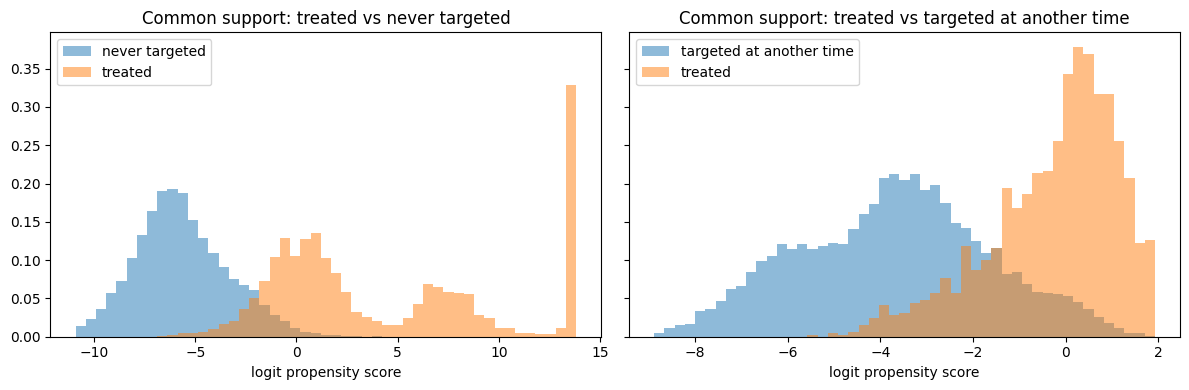

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for a, g in zip(ax, groups):
    d = m[g]
    bins = np.linspace(d.lps.quantile(.005), d.lps.quantile(.995), 50)
    a.hist(d.loc[~d.treated, 'lps'], bins, density=True, alpha=.5, label=groups[g])
    a.hist(d.loc[d.treated, 'lps'], bins, density=True, alpha=.5, label='treated')
    a.set(title=f'Common support: treated vs {groups[g]}', xlabel='logit propensity score'); a.legend()
plt.tight_layout(); plt.savefig(FIG/'07_common_support.png', dpi=150); plt.show()

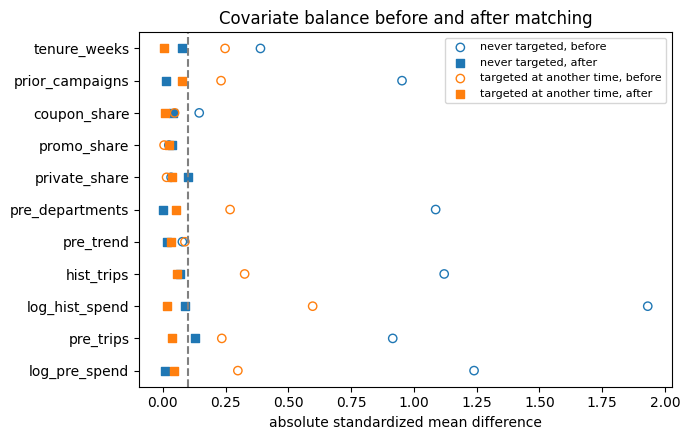

never         other       
                before  after before  after
log_pre_spend    1.240 -0.007  0.299  0.045
pre_trips        0.916  0.130  0.235  0.038
log_hist_spend   1.932 -0.087  0.597  0.015
hist_trips       1.121  0.068  0.326  0.058
pre_trend       -0.078 -0.018 -0.088 -0.034
pre_departments  1.087 -0.002  0.268  0.052
private_share   -0.033 -0.099 -0.015  0.037
promo_share      0.024 -0.037  0.005  0.025
coupon_share     0.145  0.042  0.047 -0.007
prior_campaigns  0.953  0.013  0.232  0.076
tenure_weeks    -0.389  0.075  0.248 -0.005

In [8]:
bal = pd.concat({(g, s): smd(d, m[g]) for g in groups for s, d in (('before', m[g].assign(w=1.0)), ('after', m[g][m[g].matched]))}, axis=1).round(3)
fig, ax = plt.subplots(figsize=(7, 4.5))
for (g, s), mk in zip(bal.columns, ['o', 's', 'o', 's']):
    ax.scatter(bal[(g, s)].abs(), X, marker=mk, facecolors='none' if s == 'before' else f'C{list(groups).index(g)}', edgecolors=f'C{list(groups).index(g)}', label=f'{groups[g]}, {s}')
ax.axvline(.1, ls='--', c='grey'); ax.set(xlabel='absolute standardized mean difference', title='Covariate balance before and after matching'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/'07_balance.png', dpi=150); plt.show()
bal

## 6. Difference-in-differences
For each unit, `dy` is its average weekly outcome during the campaign minus its average in the pre-period. The regression

`dy ~ treated + C(campaign)`, weighted by the matching weights, standard errors clustered by household

gives the DiD estimate. Campaign dummies make it a weighted average of the within-campaign comparisons, so treated households are never compared with controls from another campaign's weeks. Because the panel is balanced, this equals a two-way fixed effects model with unit and week effects inside each stack.

The first table shows how the estimate changes as the design gets stricter. The naive comparison uses only the campaign weeks. The unmatched DiD removes fixed spending differences but still compares heavy targeted households with light never-targeted ones, whose spending trends can differ.

In [9]:
def did(df, y, post='during', pre='pre'):
    d = df.dropna(subset=['w', f'{y}_{post}', f'{y}_{pre}']).assign(dy=lambda x: x[f'{y}_{post}'] - x[f'{y}_{pre}'])
    r = smf.wls('dy ~ treated + C(campaign)', d, weights=d.w).fit(cov_type='cluster', cov_kwds={'groups': d.household_key})
    b, (lo, hi), base = r.params['treated[T.True]'], r.conf_int().loc['treated[T.True]'], d.loc[d.treated, f'{y}_{pre}'].mean() or np.nan
    return dict(estimate=b, ci_low=lo, ci_high=hi, p=r.pvalues['treated[T.True]'], pct_of_pre=100 * b / base,
                treated_pre_mean=base, n_treated=int(d.treated.sum()), n_controls=int((~d.treated).sum()))
res = []
add = lambda analysis, group, y, **k: res.append(dict(analysis=analysis, control_group=group, outcome=y, **k))
naive = u[u.grp.isin(['treated', 'never'])].assign(w=1.0, spend_zero=0.0)
add('1. naive: campaign weeks only', 'never', 'spend', **did(naive, 'spend', 'during', 'zero'))
add('2. DiD, unmatched', 'never', 'spend', **did(naive, 'spend'))
for g in groups:
    add('3. DiD, matched', g, 'spend', **did(m[g], 'spend'))
show = lambda r: pd.DataFrame(r).round({'estimate': 2, 'ci_low': 2, 'ci_high': 2, 'p': 4, 'pct_of_pre': 1, 'treated_pre_mean': 2})
show(res)

,analysis,control_group,outcome,estimate,ci_low,ci_high,p,pct_of_pre,treated_pre_mean,n_treated,n_controls
0,1. naive: campaign weeks only,never,spend,31.40,28.94,33.85,0.0000,NaN,NaN,2140,18100
1,"2. DiD, unmatched",never,spend,1.83,0.63,3.02,0.0027,4.2,43.55,2140,18100
2,"3. DiD, matched",never,spend,5.61,1.80,9.43,0.0039,12.9,43.44,1242,1180
3,"3. DiD, matched",other,spend,1.03,-0.99,3.05,0.3170,2.4,43.41,2137,2314


The naive row is simply the gap in weekly spend during the campaign between treated and never-targeted households, which is mostly who was selected. The matched rows are the estimates to trust. They are in dollars per household per week, and `pct_of_pre` expresses them relative to the treated households' own pre-period spend.

### All outcomes
Trips show whether the effect comes from more visits. Coupon product spend vs other spend shows where the extra money goes. Coupon cost is the extra discount paid out, which feeds the return on investment in section 10.

In [10]:
n0 = len(res)
for g in groups:
    for y in Y:
        add('4. outcomes, matched', g, y, **did(m[g], y))
show(res[n0:])

,analysis,control_group,outcome,estimate,ci_low,ci_high,p,pct_of_pre,treated_pre_mean,n_treated,n_controls
0,"4. outcomes, matched",never,spend,5.61,1.80,9.43,0.0039,12.9,43.44,1242,1180
1,"4. outcomes, matched",never,trips,0.25,0.08,0.41,0.0032,16.5,1.50,1242,1180
2,"4. outcomes, matched",never,coupon_spend,1.05,-0.43,2.53,0.1658,11.8,8.91,1242,1180
3,"4. outcomes, matched",never,other_spend,4.56,1.61,7.52,0.0025,13.2,34.52,1242,1180
4,"4. outcomes, matched",never,coupon_cost,0.03,-0.05,0.12,0.4411,15.2,0.22,1242,1180
5,"4. outcomes, matched",never,match_cost,0.01,-0.01,0.02,0.2837,20.1,0.04,1242,1180
6,"4. outcomes, matched",other,spend,1.03,-0.99,3.05,0.3170,2.4,43.41,2137,2314
7,"4. outcomes, matched",other,trips,-0.01,-0.08,0.06,0.7384,-0.7,1.54,2137,2314
8,"4. outcomes, matched",other,coupon_spend,0.18,-0.58,0.94,0.6382,1.6,11.56,2137,2314
9,"4. outcomes, matched",other,other_spend,0.85,-0.70,2.40,0.2838,2.7,31.85,2137,2314


## 7. Event study: were the trends parallel before the campaign?
DiD assumes that, without the campaign, treated and matched control households would have followed the same spending trend. This cannot be tested directly, but the pre-period can show whether the trends were already different before the campaign started.

For each week relative to the campaign start, the chart shows the treated minus control difference in `spend - own pre-period average`, with 95% confidence intervals. Pre-period points should sit around zero with no slope. Post-period points show how the effect develops over the first weeks of the campaign. Weeks after a campaign's end are excluded, so every post point is a campaign week.

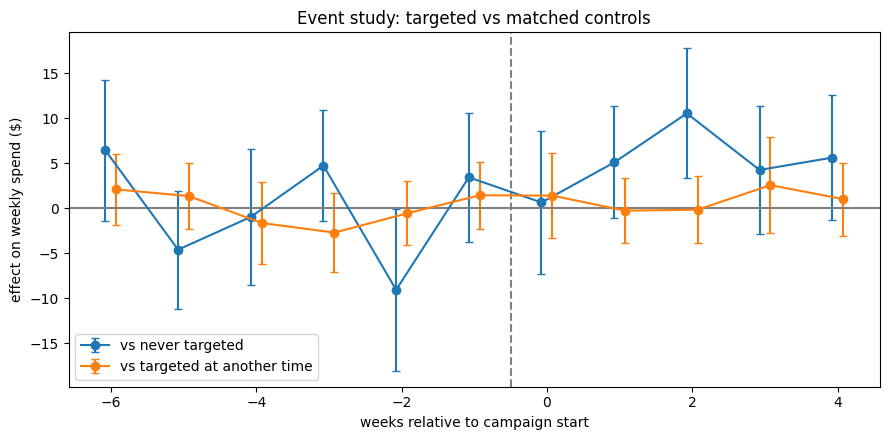

group,never,other
event_week,,
-6,6.44,2.10
-5,-4.60,1.35
-4,-0.96,-1.63
-3,4.75,-2.70
-2,-9.07,-0.56
-1,3.44,1.45
0,0.65,1.41
1,5.10,-0.26
2,10.56,-0.15


In [11]:
ev = q(f"SELECT campaign, household_key, event_week, spend FROM panel WHERE period <> 'after' AND event_week <= 4")
es = []
for g in groups:
    d = ev.merge(m[g].loc[m[g].matched, ['campaign', 'household_key', 'treated', 'w', 'spend_pre']], on=['campaign', 'household_key'])
    for e, x in d.groupby('event_week'):
        es.append(dict(group=g, event_week=e, **did(x.rename(columns={'spend': 'spend_e'}), 'spend', 'e', 'pre')))
es = pd.DataFrame(es)
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, g in enumerate(groups):
    e = es[es.group == g]
    ax.errorbar(e.event_week + (i - .5) * .15, e.estimate, yerr=[e.estimate - e.ci_low, e.ci_high - e.estimate], fmt='o-', capsize=3, label=f'vs {groups[g]}')
ax.axhline(0, c='grey'); ax.axvline(-.5, ls='--', c='grey')
ax.set(xlabel='weeks relative to campaign start', ylabel='effect on weekly spend ($)', title='Event study: targeted vs matched controls'); ax.legend()
plt.tight_layout(); plt.savefig(FIG/'07_event_study.png', dpi=150); plt.show()
es.pivot(index='event_week', columns='group', values='estimate').round(2)

## 8. Placebo test and the after window
**Placebo:** the pre-period is split in half, and the last 3 weeks are treated as if the campaign had started then. No campaign was running, so the estimate should be close to zero. A clear effect here would mean the treated and control groups were already drifting apart.

**After window:** the 4 weeks after each campaign, for treated households with no new campaign in that time. If spending falls below the pre-period level, the campaign only moved purchases forward in time. If it stays above, part of the effect lasts.

In [12]:
pw = q(f"""
SELECT campaign, household_key,
       AVG(spend) FILTER (WHERE event_week < -{PRE // 2}) AS spend_early,
       AVG(spend) FILTER (WHERE event_week BETWEEN -{PRE // 2} AND -1) AS spend_late
FROM panel WHERE period = 'pre' GROUP BY ALL
""")
n0 = len(res)
for g in groups:
    add('5. placebo: fake start mid pre-period', g, 'spend', **did(m[g].merge(pw, on=['campaign', 'household_key']), 'spend', 'late', 'early'))
    ma = match(u[u.grp.isin(['treated', g]) & u.clean_after])
    for y in ('spend', 'coupon_spend'):
        add('6. after window', g, y, **did(ma, y, 'after'))
show(res[n0:])

,analysis,control_group,outcome,estimate,ci_low,ci_high,p,pct_of_pre,treated_pre_mean,n_treated,n_controls
0,5. placebo: fake start mid pre-period,never,spend,-0.58,-6.06,4.90,0.8351,-1.3,44.65,1242,1180
1,6. after window,never,spend,7.06,2.95,11.18,0.0008,18.4,38.45,962,1022
2,6. after window,never,coupon_spend,0.96,-0.26,2.19,0.1214,12.3,7.81,962,1022
3,5. placebo: fake start mid pre-period,other,spend,-1.21,-4.43,2.01,0.4604,-2.7,44.43,2137,2314
4,6. after window,other,spend,-2.10,-4.54,0.35,0.0930,-5.5,38.20,1687,2028
5,6. after window,other,coupon_spend,-0.45,-1.59,0.70,0.4425,-4.4,10.23,1687,2028


## 9. Which campaigns and which households respond?
This section uses only the main control group (targeted at another time). The never-targeted group is too different in its spending history for subgroup splits: within a spend tier, a never-targeted household is usually one of the heaviest in its own group, so the two groups drift back towards different averages after the pre-period (regression to the mean), which biases the tier estimates.

**By campaign type:** TypeA campaigns reach far more households than TypeB and TypeC (notebook 02), so they may differ in design and effect.

**By baseline spend tier:** treated households are split into thirds by their weekly spend in the baseline history (week 16 up to the start of the pre-period), and controls get the tier their own baseline spend falls into. Matching is then redone within each campaign and tier. Baseline spend is used instead of the RFM segments from notebook 04, because those segments were built from the whole two years, including the campaign weeks, so splitting by them would split by an outcome of the campaign.

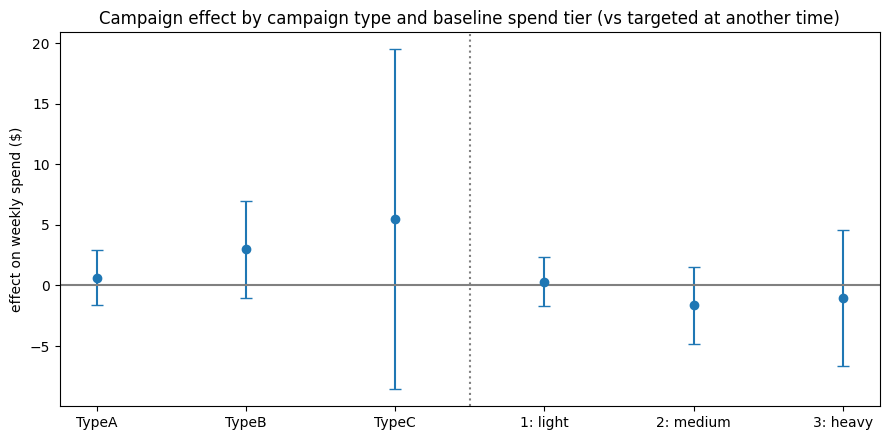

,analysis,control_group,outcome,subgroup,estimate,ci_low,ci_high,p,pct_of_pre,treated_pre_mean,n_treated,n_controls
0,7. by campaign type,other,spend,TypeA,0.65,-1.63,2.94,0.5753,1.5,42.57,1806,1546
1,7. by campaign type,other,spend,TypeB,2.97,-1.03,6.96,0.1452,6.1,48.55,316,725
2,7. by campaign type,other,spend,TypeC,5.46,-8.57,19.49,0.4455,15.1,36.26,15,43
3,8. by baseline spend tier,other,spend,1: light,0.30,-1.71,2.31,0.7715,1.4,21.34,713,1055
4,8. by baseline spend tier,other,spend,2: medium,-1.65,-4.82,1.52,0.3082,-4.5,36.81,713,555
5,8. by baseline spend tier,other,spend,3: heavy,-1.01,-6.62,4.60,0.7240,-1.4,72.16,711,494


In [13]:
n0 = len(res)
cuts = u.loc[u.treated, 'hist_spend'].quantile([1 / 3, 2 / 3]).values
tier = lambda s: np.select([s < cuts[0], s < cuts[1]], ['1: light', '2: medium'], '3: heavy')
for t, d in m['other'].groupby('type'):
    add('7. by campaign type', 'other', 'spend', subgroup=t, **did(d, 'spend'))
mt = match(u[u.grp.isin(['treated', 'other'])].assign(tier=lambda d: tier(d.hist_spend)), by=('campaign', 'tier'))
for t, d in mt.groupby('tier'):
    add('8. by baseline spend tier', 'other', 'spend', subgroup=t, **did(d, 'spend'))
sub = show(res[n0:])
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.errorbar(sub.subgroup, sub.estimate, yerr=[sub.estimate - sub.ci_low, sub.ci_high - sub.estimate], fmt='o', capsize=4)
ax.axhline(0, c='grey'); ax.axvline(2.5, ls=':', c='grey')
ax.set(ylabel='effect on weekly spend ($)', title='Campaign effect by campaign type and baseline spend tier (vs targeted at another time)')
plt.tight_layout(); plt.savefig(FIG/'07_effect_by_group.png', dpi=150); plt.show()
sub

## 10. Return on coupon spend
Both the extra sales and the extra coupon cost come from the same DiD, so they are measured on the same households over the same weeks.

- **All coupon cost** assumes the retailer pays every coupon dollar. This is the worst case, since manufacturers usually fund their own coupons.
- **Retailer match cost** counts only the retailer's match of manufacturer coupons, the part it certainly pays.

Revenue is not profit, so the key figure is the **break-even gross margin**: incremental coupon cost divided by incremental sales. The campaign pays for its coupons if the retailer's gross margin on the extra sales is above this figure. Printing, mailing and staff costs are not in the data, so the true break-even is higher.

In [14]:
r = pd.DataFrame(res).query("analysis == '4. outcomes, matched'").set_index(['control_group', 'outcome'])
weeks = {g: m[g].loc[m[g].treated & m[g].matched, 'weeks_during'].mean() for g in groups}
roi = pd.DataFrame({groups[g]: {
    'incremental sales per household per week ($)': r.loc[(g, 'spend'), 'estimate'],
    'sales effect p-value': r.loc[(g, 'spend'), 'p'],
    'average campaign length (weeks)': weeks[g],
    'incremental sales per household per campaign ($)': r.loc[(g, 'spend'), 'estimate'] * weeks[g],
    'incremental coupon cost per household per campaign ($)': r.loc[(g, 'coupon_cost'), 'estimate'] * weeks[g],
    'incremental retailer match cost per household per campaign ($)': r.loc[(g, 'match_cost'), 'estimate'] * weeks[g],
    'break-even margin, all coupon cost (%)': 100 * r.loc[(g, 'coupon_cost'), 'estimate'] / r.loc[(g, 'spend'), 'estimate'],
    'break-even margin, retailer match only (%)': 100 * r.loc[(g, 'match_cost'), 'estimate'] / r.loc[(g, 'spend'), 'estimate']} for g in groups}).round(3)
roi

,never targeted,targeted at another time
incremental sales per household per week ($),5.612,1.030
sales effect p-value,0.004,0.317
average campaign length (weeks),6.655,6.785
incremental sales per household per campaign ($),37.349,6.986
incremental coupon cost per household per campaign ($),0.224,0.447
incremental retailer match cost per household per campaign ($),0.053,0.066
"break-even margin, all coupon cost (%)",0.600,6.395
"break-even margin, retailer match only (%)",0.142,0.940


A break-even margin is only meaningful when the sales effect is clearly positive. If the sales effect's confidence interval includes zero, the coupon cost is not shown to be recovered, whatever the ratio looks like.

## 11. Save results
All estimates go to one long table, ready for the Power BI dashboard in notebook 08.

In [15]:
out = pd.concat([pd.DataFrame(res), es.assign(analysis='9. event study', control_group=es.group, outcome='spend', subgroup=es.event_week.astype(str)).drop(columns=['group', 'event_week'])]).fillna({'subgroup': 'all'})
con.execute(f"COPY (SELECT * FROM out) TO '{DATA/'campaign_effects.parquet'}' (FORMAT PARQUET)")
q(f"SELECT analysis, COUNT(*) AS rows FROM '{DATA/'campaign_effects.parquet'}' GROUP BY 1 ORDER BY 1")

,analysis,rows
0,1. naive: campaign weeks only,1
1,"2. DiD, unmatched",1
2,"3. DiD, matched",2
3,"4. outcomes, matched",12
4,5. placebo: fake start mid pre-period,2
5,6. after window,4
6,7. by campaign type,3
7,8. by baseline spend tier,3
8,9. event study,22


## Findings

1. **The design keeps about 30% of all targetings, most of them from TypeA.** With a 6-week pre-period, 2,210 of the 7,208 household-campaign targetings have a clean window, and 2,140 of those households shopped in the pre-period. They come from 27 of the 30 campaigns, but TypeA provides 85% of them (1,806 of the 2,137 matched treated units). Most TypeB and TypeC households were in another campaign at the same time, so the results mainly describe TypeA campaigns.
2. **Selection explains almost all of the naive gap.** During campaign weeks, targeted households spent $31.40 a week more than never-targeted ones. After matching on pre-campaign behaviour and comparing changes instead of levels, the main estimate is **+$1.03 a week (+2.4%, 95% CI -$0.99 to +$3.05, p = 0.32)**. Over 95% of the naive gap is who was chosen, not what the campaign did.
3. **No measurable effect on spending among targeted households.** Against households targeted at another time, trips (-0.01 a week), spend on the couponed products (+$0.18) and spend on everything else (+$0.85) were all statistically unchanged. The confidence interval rules out an effect larger than about $3 a week (7% of pre-period spend). The design passes its checks: every standardized mean difference is below 0.1 after matching (largest 0.076), 99.9% of treated households found a match, the event-study points stay flat around zero both before and during the campaign, and the placebo test is close to zero (-$1.21, p = 0.46).
4. **Coupons were used, but on purchases that would have happened anyway.** Coupon discount per targeted household rose by $0.07 a week (p = 0.011, about 29% above its pre-period level), while spending did not move. The coupons mostly discounted the usual basket rather than creating extra sales.
5. **No pull-forward and no lasting lift.** In the 4 weeks after a campaign, spend was $2.10 a week lower than the controls' change (p = 0.09). That is not significant, and it points the same way as the main result: no extra spending during or after.
6. **The never-targeted comparison is not credible, as expected.** It gives +$5.61 a week (+12.9%, p = 0.004), but its effect is even larger after the campaigns ended (+$7.06, p < 0.001). A campaign cannot explain a gap that grows once it is over, so this reflects the two groups drifting apart, which is the regression-to-the-mean problem this design was built to avoid. The event study against never-targeted households also swings between -$9 and +$6 in the weeks before any campaign had started, only 58% of treated households found a match, and one covariate (pre-period trips, SMD 0.13) stays above the 0.1 balance target.
7. **No campaign type or spend tier stands out.** TypeA shows +$0.65 (p = 0.58), TypeB +$2.97 (95% CI -$1.03 to +$6.96, p = 0.15) and TypeC is too small to estimate (15 households). Light, medium and heavy baseline spenders all show effects close to zero.
8. **The coupon cost in the data is small, but the return is not proven.** At the point estimate, a targeted household spends $6.99 more per campaign for $0.45 of extra coupon discount, which would break even at a 6.4% gross margin. The sales effect is not statistically different from zero, though, so a positive return cannot be claimed. Printing, mailing and staff costs are not in the data.

**Limitations**
- The estimate is the effect of being targeted (intention to treat) for households with a clean campaign window. It does not measure the effect on a household that actually redeemed, and it says nothing about households the retailer never chose.
- Households in overlapping campaigns, often the most heavily targeted ones, are excluded, so the effect of a campaign stacked on another campaign is unknown.
- Control households were also targeted at other times. If campaigns had long-lasting effects, both groups would carry them, which would pull the estimate towards zero. Earlier campaigns received are balanced between the groups, which limits this.
- Matching with replacement reused some controls many times, and the standard errors do not include the uncertainty from estimating the propensity score.

## Recommendations
1. **Do not scale the current program on its current audience.** For the heavy, already loyal households the retailer targets, campaigns did not measurably raise spending, and the coupons mostly discounted purchases that would have happened anyway. Hold the budget flat until a better-measured test shows a return.
2. **Add a random hold-out to every campaign.** Keeping 5 to 10% of each target list untreated turns every campaign into an experiment and makes the effect measurable directly, instead of only 30% of targetings through a complex design.
3. **Stop overlapping campaigns for the same household.** Overlaps made 70% of targetings impossible to evaluate. Giving each household at most one campaign at a time costs little and makes every campaign measurable.
4. **Test campaigns on households with room to grow.** The current targeting favours heavy shoppers (treated households averaged $43.55 a week before their campaign). A randomized pilot on at-risk households (notebook 04) and on households that break their shopping rhythm (notebook 05) would show whether offers work better where there is spending left to win.
5. **Give TypeB a properly powered test before cutting it.** Its point estimate is the largest (+6%), but it rests on only 316 clean households, so the data cannot confirm or rule out a real effect.